## Following tutorials on quantstart.com to learn about how to simulate Brownian motion

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
#Use a seed value ( pseudo random number generator) to get reproducible results.
rng = np.random.default_rng(42)

In [3]:
#choose the number of paths and steps
paths = 50
points = 1000

In [4]:
#Standard brownian motion
# mean = 0
# volatility = 1 (standard deviation)
mu, sigma = 0.0, 1.0

In [5]:
#Get the necessary samples from normal distribution

In [6]:
Z = rng.normal(mu, sigma, (paths, points))

In [7]:
interval = [0.0, 1.0]
dt = (interval[1] - interval[0]) / (points - 1)

In [8]:
t_axis = np.linspace(interval[0], interval[1], points)

In [9]:
W = np.zeros((paths, points))
for idx in range(points - 1):
    real_idx = idx + 1
    W[:, real_idx] = W[:, real_idx - 1] + np.sqrt(dt) * Z[:, idx]

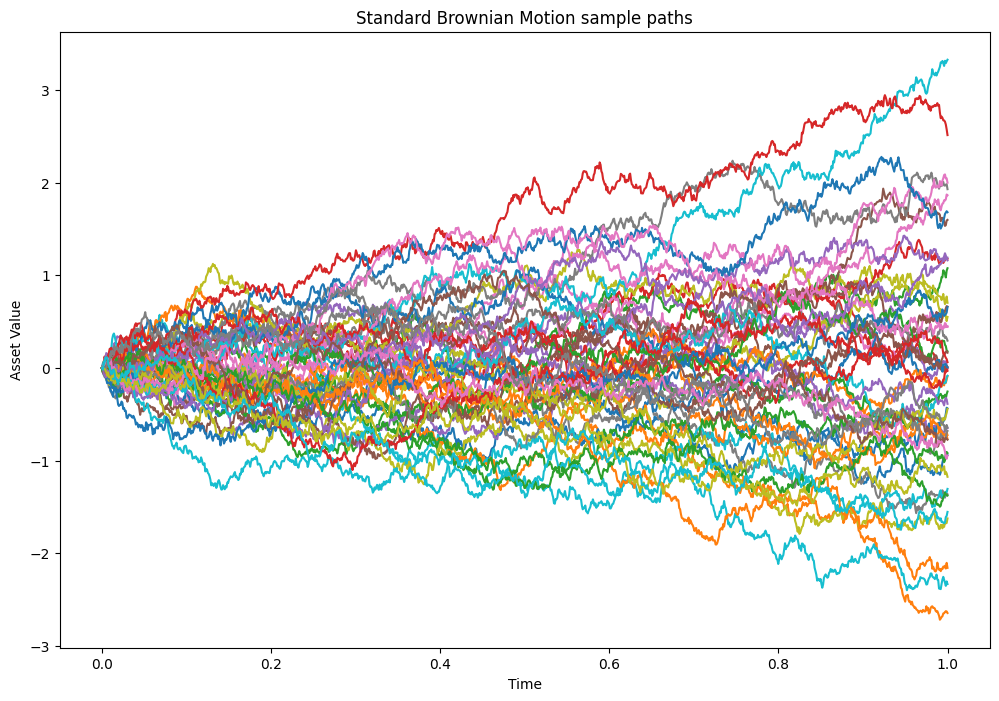

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(t_axis, W[path, :])
ax.set_title("Standard Brownian Motion sample paths")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")
plt.show()

In [13]:
# Results:
# 1.Most of the paths are clustering near 0 when t = 1

In [16]:
#Use kernal density estimate - to estimate continuous probability distribution of the final values

In [17]:
final_values = pd.DataFrame({'final_values': W[:, -1]})

In [18]:
final_values.head(5)

,final_values
0,-0.940151
1,-2.644750
2,1.076830
3,-0.006508
4,-0.647476


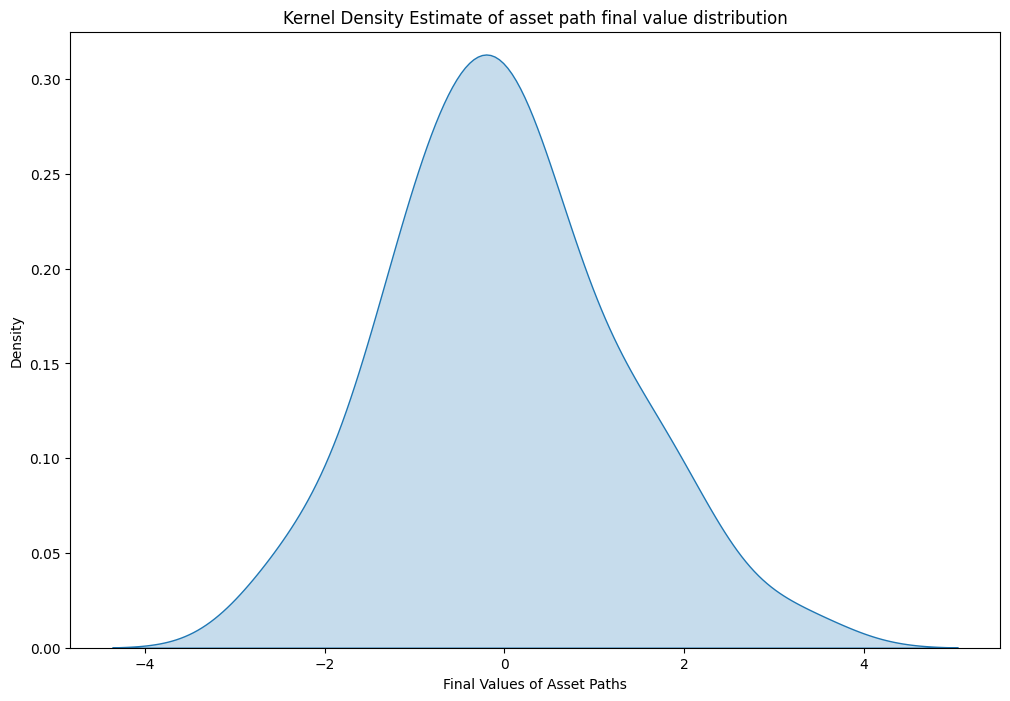

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sns.kdeplot(data=final_values, x='final_values', fill=True, ax=ax)
ax.set_title("Kernel Density Estimate of asset path final value distribution")
ax.set_ylim(0.0, 0.325)
ax.set_xlabel('Final Values of Asset Paths')
plt.show()

In [20]:
#Close to a standard normal distribution

In [21]:
print(final_values.mean(), final_values.std())

final_values   -0.011699
dtype: float64 final_values    1.251382
dtype: float64


In [22]:
#If we had calculated more paths it would be even closer to the standard normal distribution of mu = 0 and std = 1

### Constant Drift and Volatility Brownian Motion

In [23]:
mu_c, sigma_c = 5,2

In [24]:
X = np.zeros((paths, points))
for idx in range(points - 1):
    real_idx = idx + 1
    X[:, real_idx] = X[:, real_idx - 1] + mu_c * dt + sigma_c * np.sqrt(dt) * Z[:, idx]

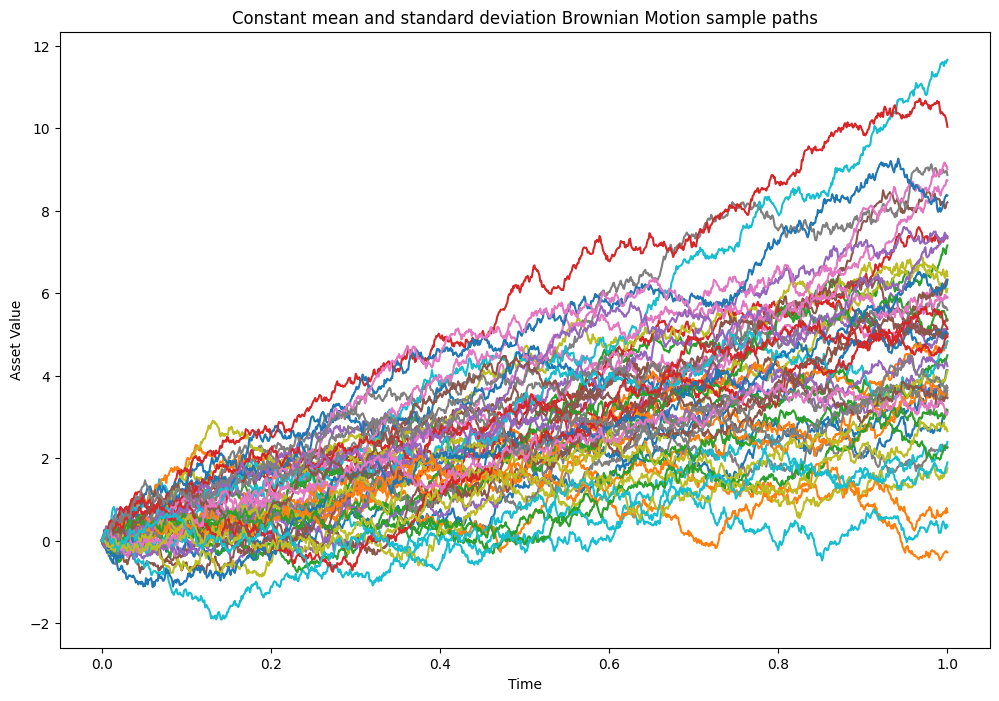

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(t_axis, X[path, :])
ax.set_title("Constant mean and standard deviation Brownian Motion sample paths")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")
plt.show()

### Geometric Brownian Motion

In [26]:
# Parameters
S0 = 100
mu = 0.10
sigma = 0.20

S = S0 * np.exp(
    (mu - 0.5 * sigma**2) * t_axis
    + sigma * W
)

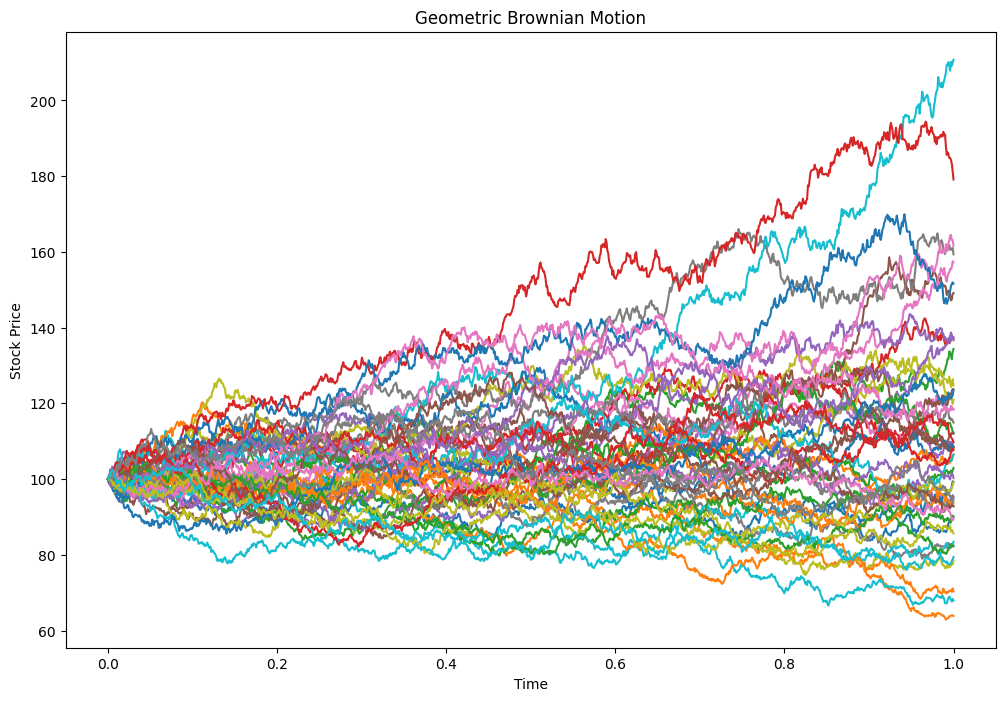

In [27]:
fig, ax = plt.subplots(figsize=(12,8))

for i in range(paths):
    ax.plot(t_axis, S[i])

ax.set_title("Geometric Brownian Motion")
ax.set_xlabel("Time")
ax.set_ylabel("Stock Price")
plt.show()

In [28]:
#Distribution of final values

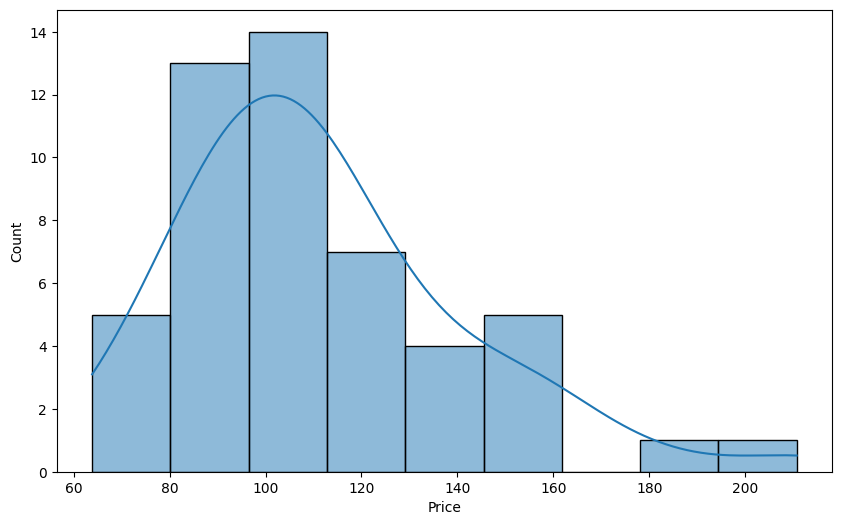

            Price
count   50.000000
mean   111.534048
std     29.448564
min     63.829803
25%     92.830094
50%    107.930437
75%    123.644115
max    210.756377


In [29]:
final_prices = pd.DataFrame({
    "Price": S[:, -1]
})

fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(final_prices,
             x="Price",
             kde=True,
             ax=ax)

plt.show()

print(final_prices.describe())